# Cape Cauldron coherent vortices

The Cape Cauldron is the Agulhas-ring corridor south-west of South Africa.
Haller & Beron-Vera (2013,
[doi:10.1017/jfm.2013.391](https://doi.org/10.1017/jfm.2013.391)) found
coherent Lagrangian vortices there with the construction this notebook uses.

The FTLE ridges of `cabo_verde_ftle` mark hyperbolic stretching. A coherent
Lagrangian vortex is a region that stays together as it advects, bounded by a
material loop that stretches uniformly. From the same Cauchy–Green tensor
$C = (\nabla F)^\top \nabla F$, with eigenpairs $C\xi_i = \lambda_i \xi_i$ and
$0 < \lambda_1 \le \lambda_2$, Haller & Beron-Vera (2013, Eq. 14) build the
direction fields

$$
\eta_\lambda^{\pm} = \sqrt{\frac{\lambda_2 - \lambda^2}{\lambda_2 - \lambda_1}}\,\xi_1
  \;\pm\; \sqrt{\frac{\lambda^2 - \lambda_1}{\lambda_2 - \lambda_1}}\,\xi_2 \,,
$$

defined where $\lambda_1 < \lambda^2 < \lambda_2$. They satisfy
$|\nabla F\,\eta_\lambda| = \lambda$ at every point, so a curve tangent to one
has its arc length multiplied by $\lambda$ over the window. A closed curve
tangent to one is a *closed shear line*. Each vortex holds a nested family of
them over $\lambda$, and the outermost member is its boundary.

`closed_shear_lines` finds them with the return map of Haller & Beron-Vera
(2013). Lines are launched along a section running east or west from a
candidate centre and traced until they cross it again, and a launch that comes
back to itself is a closed orbit.

In [1]:
# Importing Parcels pulls in the holoviews/bokeh bootstrap and prints an
# alpha-version notice, neither of which belongs on the rendered page.
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from parcels import FieldSet, Particle, ParticleSet, StatusCode
from parcels.convert import copernicusmarine_to_sgrid
from parcels.kernels import AdvectionRK4

from lcs_parcels import (
    NeighborSeedGrid,
    closed_shear_lines,
    elliptic_centres,
    outermost_shear_lines,
    stretch_range,
)

/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_55529/2914286310.py:6: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  from parcels import FieldSet, Particle, ParticleSet, StatusCode


## Currents

Daily-mean GLORYS12 reanalysis surface currents at 1/12 degree, the local file
that `get_data`
writes.

In [2]:
currents = xr.open_dataset("data/cape_cauldron_glorys_daily.nc").load()
currents

<xarray.Dataset> Size: 136MB
Dimensions:    (time: 34, depth: 1, latitude: 385, longitude: 433)
Coordinates:
  * time       (time) datetime64[ns] 272B 2018-05-31 2018-06-01 ... 2018-07-03
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 2kB -52.0 -51.92 -51.83 ... -20.08 -20.0
  * longitude  (longitude) float32 2kB -6.0 -5.917 -5.833 ... 29.83 29.92 30.0
Data variables:
    uo         (time, depth, latitude, longitude) float64 45MB 0.07508 ... nan
    vo         (time, depth, latitude, longitude) float64 45MB 0.05005 ... nan
    zos        (time, latitude, longitude) float64 45MB -1.443 -1.442 ... nan
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574
    copernicusmarine_version:  2.4.1

## Parcels v4 field set

`copernicusmarine_to_sgrid` tags the CMEMS A-grid with SGRID metadata, and
`from_sgrid_conventions` wraps it as a spherical `FieldSet`.

In [3]:
sgrid = copernicusmarine_to_sgrid(fields={"U": currents["uo"], "V": currents["vo"]})
fieldset = FieldSet.from_sgrid_conventions(sgrid, mesh="spherical")
z_surface = float(currents["depth"].values[0])

## Seed grid and window

A box across the Cape Cauldron at 1/25 degree, released on 2018-06-01 and read
at 15 days. An Agulhas ring turns once in roughly 7 to 12 days, so the window
covers one to two revolutions. Over 30 days the model's loops stop stretching
uniformly and the search closes almost none. A vortex boundary belongs to one
window, so only the forward flow map is needed.

In [4]:
t0 = np.datetime64("2018-06-01")
T = np.timedelta64(15, "D")
lon_axis = np.arange(2.0, 22.0 + 1e-9, 1 / 25)
lat_axis = np.arange(-44.0, -28.0 + 1e-9, 1 / 25)
seed = NeighborSeedGrid.from_axes(lon=lon_axis, lat=lat_axis)
seed

<NeighborSeedGrid 501x401 grid, lon 2.00..22.00, lat -44.00..-28.00>

## Recovery kernel

Particles that leave the domain or hit land are turned into `NaN` in place
(Parcels would otherwise abort the run), so losses propagate as `NaN`
through every diagnostic below. The kernel sets `StatusCode.EndofLoop`
rather than `StatusCode.Delete`, because deleting shrinks the particle
array and breaks the alignment with the seed order.

In [5]:
def set_lost_to_nan(particles, fieldset):
    lost = particles.state >= StatusCode.Error
    particles.x = np.where(lost, np.nan, particles.x)
    particles.y = np.where(lost, np.nan, particles.y)
    particles.state = np.where(lost, StatusCode.EndofLoop, particles.state)

## Advect forward

In [6]:
lon, lat = seed.to_parcels_pset()
z = np.full(len(lon), z_surface)
pset = ParticleSet(fieldset, pclass=Particle, x=lon, y=lat, z=z, t=t0)
pset.execute(
    [AdvectionRK4, set_lost_to_nan],
    dt=np.timedelta64(1, "h"),
    runtime=T,
    verbose_progress=False,
)

In [7]:
forward = seed.pset_to_flowmap(lon=pset.x, lat=pset.y, t0=t0, t1=t0 + T)
forward

<NeighborFlowMap 501x401 grid, lon 2.00..22.00, lat -44.00..-28.00,
                 t0 2018-06-01T00:00:00, T +15.0 days>

A second run over the first day gives the rotation of the flow. The polar
rotation angle is defined modulo $2\pi$, and an Agulhas ring turns several
times in 15 days, so its sign gives the rotation sense only over a short
window.

In [8]:
pset_day = ParticleSet(fieldset, pclass=Particle, x=lon, y=lat, z=z, t=t0)
pset_day.execute(
    [AdvectionRK4, set_lost_to_nan],
    dt=np.timedelta64(1, "h"),
    runtime=np.timedelta64(1, "D"),
    verbose_progress=False,
)
first_day = seed.pset_to_flowmap(
    lon=pset_day.x, lat=pset_day.y, t0=t0, t1=t0 + np.timedelta64(1, "D")
)
first_day

<NeighborFlowMap 501x401 grid, lon 2.00..22.00, lat -44.00..-28.00,
                 t0 2018-06-01T00:00:00, T +1.0 days>

Particles lost to land or to the domain edge over the 15 days.

In [9]:
int(np.isnan(np.asarray(pset.x)).sum())

19016

## Eigendecomposition and FTLE

The FTLE is the backdrop the centres and the boundaries are drawn on below.
Cells that contract in every direction have a negative FTLE, which would
centre the colour range on zero, so it starts at 0.

In [10]:
eigen = forward.cg_eigen()
eigen

<xarray.Dataset> Size: 13MB
Dimensions:   (i: 501, j: 401, eig: 2, comp: 2)
Coordinates:
  * i         (i) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499 500
  * j         (j) int64 3kB 0 1 2 3 4 5 6 7 ... 393 394 395 396 397 398 399 400
    lon_grid  (i, j) float64 2MB 2.0 2.0 2.0 2.0 2.0 ... 22.0 22.0 22.0 22.0
    lat_grid  (i, j) float64 2MB -44.0 -43.96 -43.92 ... -28.08 -28.04 -28.0
  * eig       (eig) int64 16B 0 1
  * comp      (comp) <U1 8B 'x' 'y'
    t0        datetime64[s] 8B 2018-06-01
    T         timedelta64[s] 8B 15 days
Data variables:
    lambda    (i, j, eig) float64 3MB nan nan nan nan nan ... nan nan nan nan
    xi        (i, j, comp, eig) float64 6MB nan nan nan nan ... nan nan nan nan

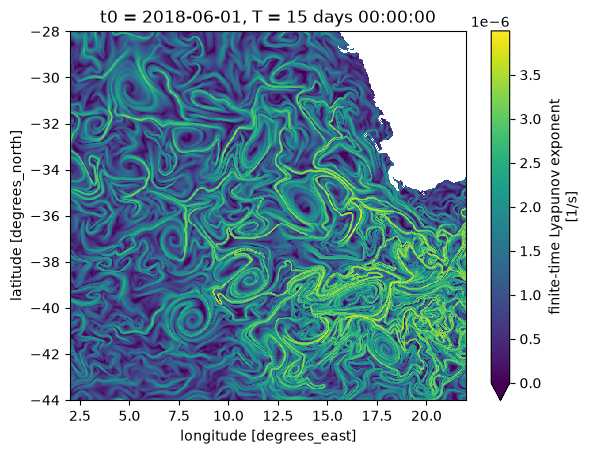

In [11]:
ftle = forward.ftle()
ftle.plot.pcolormesh(x="lon_grid", y="lat_grid", vmin=0.0)

## Where $\eta_\lambda$ exists, at $\lambda = 1$

$\eta_1$ needs $\lambda_1 < 1 < \lambda_2$, a neighbourhood stretched along one
eigendirection and contracted along the other. Where that fails, no direction
has a stretching factor of 1, and a traced line ends.

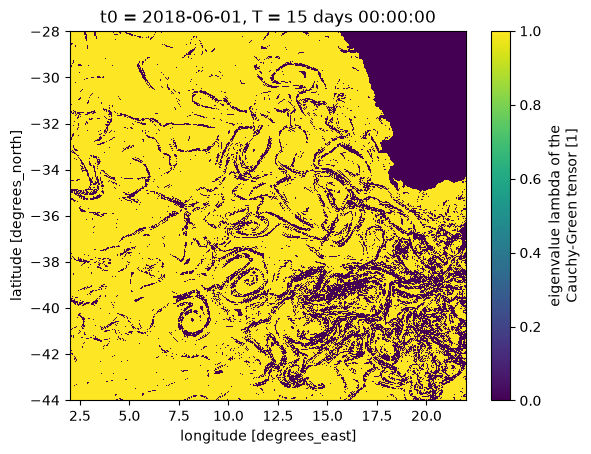

In [12]:
lambda1 = eigen["lambda"].isel(eig=0)
lambda2 = eigen["lambda"].isel(eig=1)
((lambda1 < 1.0) & (1.0 < lambda2)).plot.pcolormesh(x="lon_grid", y="lat_grid")

## How far from area-preserving

$|\det \nabla F| = \sqrt{\lambda_1\lambda_2}$ is the area change of a grid cell
over the window. A loop whose interior changes area by $J$ and keeps its shape
changes its length by $\sqrt{J}$, so a boundary closes near
$\lambda = \sqrt{J}$ rather than at 1, and the search scans a range of
$\lambda$.

In [13]:
np.sqrt(lambda1 * lambda2).quantile([0.05, 0.25, 0.5, 0.75, 0.95])

<xarray.DataArray 'lambda' (quantile: 5)> Size: 40B
array([  0.25487816,   0.75385947,   1.27962822,   6.47093038,
       170.83215012])
Coordinates:
  * quantile  (quantile) float64 40B 0.05 0.25 0.5 0.75 0.95
Attributes:
    long_name:  eigenvalue lambda of the Cauchy-Green tensor
    units:      1

## Candidate centres

Windowed minima of $\lambda_2 / \lambda_1$, the points where the
eigendirections come closest to undefined, over a 100 km window and at least
50 km from the domain edge and from land.

In [14]:
anisotropy = (lambda2 / lambda1).assign_attrs(
    long_name="Cauchy-Green eigenvalue ratio", units="1"
)
centres = elliptic_centres(anisotropy, extremum="min", window_m=100_000.0)
centres

<xarray.Dataset> Size: 6kB
Dimensions:  (centre: 241)
Coordinates:
  * centre   (centre) int64 2kB 0 1 2 3 4 5 6 7 ... 234 235 236 237 238 239 240
Data variables:
    lon      (centre) float64 2kB 2.68 2.72 2.88 2.92 ... 21.28 21.32 21.36
    lat      (centre) float64 2kB -34.96 -41.52 -38.96 ... -41.44 -37.04 -42.48
Attributes:
    extremum:          min
    edge_m:            50000.0
    edge_cells_i:      14
    edge_cells_j:      12
    window_m:          100000.0
    window_cells_i:    27
    window_cells_j:    21
    grid_spacing_i_m:  3598.343413748942
    grid_spacing_j_m:  4447.797065782255

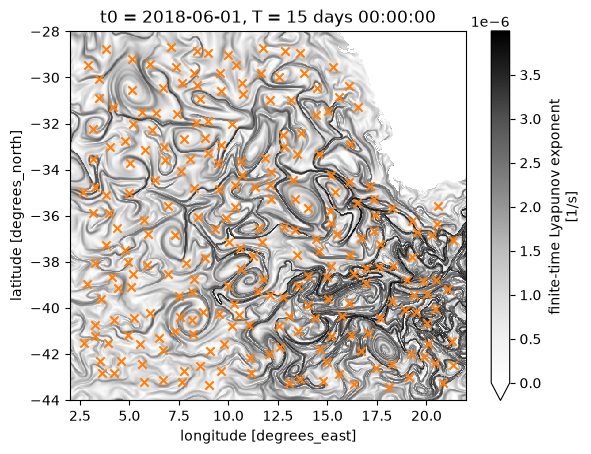

In [15]:
_, ax = plt.subplots()
ftle.plot.pcolormesh(x="lon_grid", y="lat_grid", vmin=0.0, ax=ax, cmap="Greys")
ax.scatter(centres["lon"], centres["lat"], marker="x", color="tab:orange")
plt.show()

## The scan over $\lambda$

`stretch_range` is the default scan, log-symmetric about 1 from $1/1.5$ to
$1.5$ in steps of 0.03 in $\ln \lambda$, so it covers boundaries that shrink
and boundaries that grow.

In [16]:
stretches = stretch_range(stretch_max=1.5, step=0.03)
stretches

array([0.67705687, 0.69767633, 0.71892373, 0.74081822, 0.76337949,
       0.78662786, 0.81058425, 0.83527021, 0.86070798, 0.88692044,
       0.91393119, 0.94176453, 0.97044553, 1.        , 1.03045453,
       1.06183655, 1.09417428, 1.12749685, 1.16183424, 1.19721736,
       1.23367806, 1.27124915, 1.30996445, 1.34985881, 1.39096813,
       1.43332941, 1.47698079])

## Closed shear lines

Every closed orbit at every centre, stretching factor and branch, from two
sections running 150 km due east and due west of each centre.

In [17]:
orbits = closed_shear_lines(
    forward,
    centre_lon=centres["lon"],
    centre_lat=centres["lat"],
    stretches=stretches,
    max_radius_m=150_000.0,
)
orbits

<xarray.Dataset> Size: 882kB
Dimensions:     (orbit: 192, point: 282)
Coordinates:
  * orbit       (orbit) int64 2kB 0 1 2 3 4 5 6 ... 185 186 187 188 189 190 191
  * point       (point) int64 2kB 0 1 2 3 4 5 6 ... 275 276 277 278 279 280 281
Data variables:
    lon         (orbit, point) float64 433kB 5.668 5.664 5.659 ... nan nan nan
    lat         (orbit, point) float64 433kB -30.56 -30.54 -30.53 ... nan nan
    centre      (orbit) int64 2kB 36 36 36 30 30 30 ... 163 240 240 240 240 240
    centre_lon  (orbit) float64 2kB 5.12 5.12 5.12 4.76 ... 21.36 21.36 21.36
    centre_lat  (orbit) float64 2kB -30.56 -30.56 -30.56 ... -42.48 -42.48
    stretch     (orbit) float64 2kB 1.0 0.9704 1.0 ... 0.6977 0.7189 0.7634
    branch      (orbit) int64 2kB 1 1 1 -1 -1 -1 -1 -1 ... -1 -1 -1 -1 -1 -1 -1
    area_m2     (orbit) float64 2kB 8.782e+09 1.26e+10 ... 6.481e+08 1.033e+09
    radius_m    (orbit) float64 2kB 5.287e+04 6.333e+04 ... 1.436e+04 1.813e+04
    residual_m  (orbit) float64 2kB 45.92 142.3 58.86 ... 271.6 298.1 1.634e+03
Attributes:
    stretch_min:       0.6770568744981647
    stretch_max:       1.4769807938826427
    n_stretch:         27
    max_radius_m:      150000.0
    launch_spacing_m:  3598.343413748942
    step_m:            1799.171706874471
    closure_tol_m:     1799.171706874471
    n_centres:         241
    n_never_returned:  25573

Each orbit's equivalent radius against the $\lambda$ it closed at. One vortex
shows up as a run of orbits growing with $\lambda$.

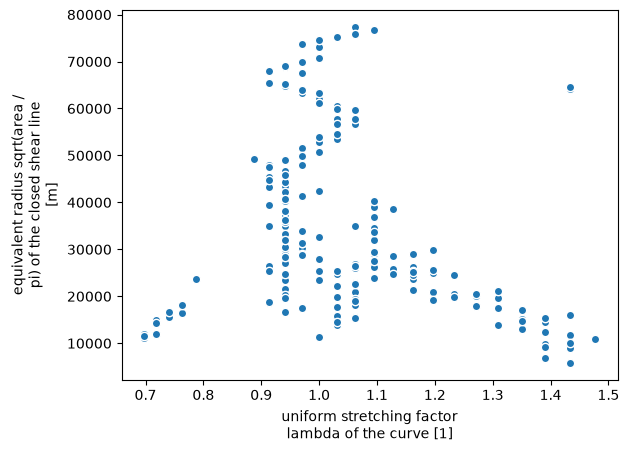

In [18]:
orbits.plot.scatter(x="stretch", y="radius_m")
plt.show()

## The outermost boundary per vortex

`outermost_shear_lines` keeps the largest orbit per centre and merges centres
that one boundary encloses. `rotation_sense` is the sign of the first day's
polar rotation angle inside the boundary, counter-clockwise positive. South of
the equator a clockwise eddy is cyclonic.

In [19]:
eddies = outermost_shear_lines(orbits, rotation=first_day.polar_rotation())
eddies

<xarray.Dataset> Size: 58kB
Dimensions:         (eddy: 12, point: 282)
Coordinates:
  * eddy            (eddy) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
    orbit_index     (eddy) int64 96B 64 101 117 33 8 176 95 128 100 186 191 166
  * point           (point) int64 2kB 0 1 2 3 4 5 6 ... 276 277 278 279 280 281
Data variables: (12/13)
    lon             (eddy, point) float64 27kB 5.909 5.901 5.893 ... nan nan nan
    lat             (eddy, point) float64 27kB -30.56 -30.55 -30.53 ... nan nan
    centre          (eddy) int64 96B 36 72 73 34 30 141 50 76 63 163 240 84
    centre_lon      (eddy) float64 96B 5.12 7.76 7.76 5.04 ... 14.0 21.36 8.4
    centre_lat      (eddy) float64 96B -30.56 -42.72 -32.68 ... -42.48 -28.84
    stretch         (eddy) float64 96B 1.062 1.433 0.8869 ... 0.7866 0.7634 1.0
    ...              ...
    area_m2         (eddy) float64 96B 1.882e+10 1.312e+10 ... 3.959e+08
    radius_m        (eddy) float64 96B 7.74e+04 6.463e+04 ... 1.123e+04
    residual_m      (eddy) float64 96B 124.9 1.527e+03 ... 1.634e+03 1.474e+03
    centroid_lon    (eddy) float64 96B 5.199 7.107 7.938 ... 13.93 21.35 8.338
    centroid_lat    (eddy) float64 96B -30.59 -42.62 -32.68 ... -42.6 -28.94
    rotation_sense  (eddy) int64 96B 1 -1 1 -1 -1 -1 1 1 1 -1 -1 1
Attributes:
    stretch_min:            0.6770568744981647
    stretch_max:            1.4769807938826427
    n_stretch:              27
    max_radius_m:           150000.0
    launch_spacing_m:       3598.343413748942
    step_m:                 1799.171706874471
    closure_tol_m:          1799.171706874471
    n_centres:              241
    n_never_returned:       25573
    n_orbits_in:            192
    n_centres_with_orbits:  13

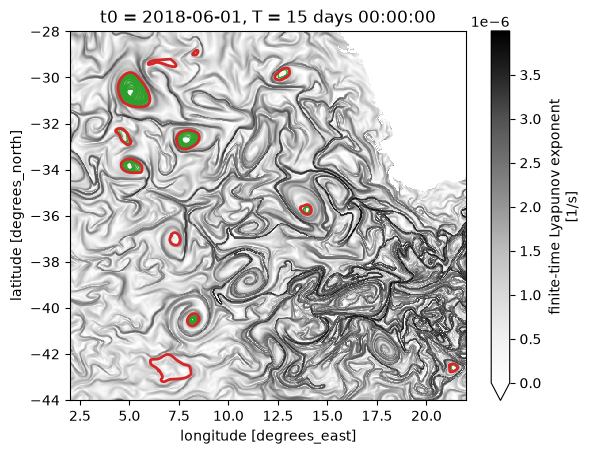

In [20]:
_, ax = plt.subplots()
ftle.plot.pcolormesh(x="lon_grid", y="lat_grid", vmin=0.0, ax=ax, cmap="Greys")
ax.plot(orbits["lon"].T, orbits["lat"].T, color="tab:green", lw=0.5)
ax.plot(eddies["lon"].T, eddies["lat"].T, color="tab:red", lw=2.0)
plt.show()

## The polar rotation angle

The rotation over the first day, which $C$ discards, with the boundaries on
top.

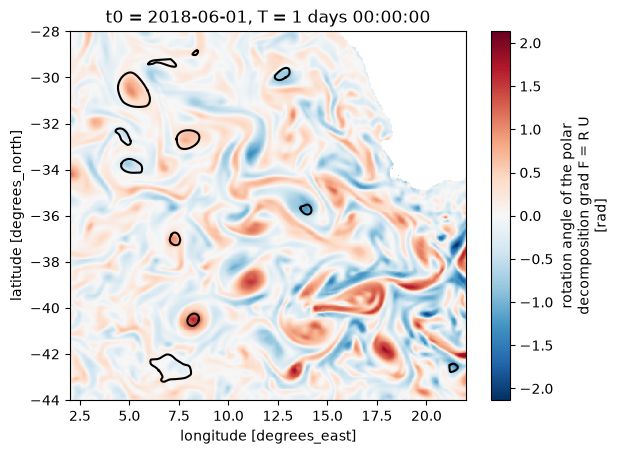

In [21]:
_, ax = plt.subplots()
first_day.polar_rotation().plot.pcolormesh(x="lon_grid", y="lat_grid", ax=ax)
ax.plot(eddies["lon"].T, eddies["lat"].T, color="black", lw=1.5)
plt.show()

## Material check

A boundary stretches every tangent element by its $\lambda$, so its arc length
over the window should grow by that factor. `forward.image` carries a curve
through the flow map already computed, with no second Parcels run. A circle of
the same equivalent radius about the same centre is not tangent to
$\eta_\lambda$, so nothing constrains its ratio.

In [22]:
def arc_length_m(curve):
    lon, lat = curve["lon"], curve["lat"]
    lat_mid = np.deg2rad(0.5 * (lat + lat.shift(point=-1)))
    dx = 6_371_000.0 * np.cos(lat_mid) * np.deg2rad(lon.shift(point=-1) - lon)
    dy = 6_371_000.0 * np.deg2rad(lat.shift(point=-1) - lat)
    return np.hypot(dx, dy).sum("point")


boundary = eddies.isel(eddy=0)
evolved = forward.image(lon_0=boundary["lon"], lat_0=boundary["lat"])

angle = xr.DataArray(np.linspace(0.0, 2 * np.pi, 361), dims="point")
radius_deg = boundary["radius_m"] / 111_195.0
circle = xr.Dataset(
    {
        "lon": boundary["centroid_lon"]
        + radius_deg * np.cos(angle) / np.cos(np.deg2rad(boundary["centroid_lat"])),
        "lat": boundary["centroid_lat"] + radius_deg * np.sin(angle),
    }
)
evolved_circle = forward.image(lon_0=circle["lon"], lat_0=circle["lat"])

The boundary's $\lambda$, its arc-length ratio, and the circle's.

In [23]:
(
    float(boundary["stretch"]),
    float(arc_length_m(evolved) / arc_length_m(boundary)),
    float(arc_length_m(evolved_circle) / arc_length_m(circle)),
)

(1.0618365465453596, 1.1211983474691625, 3.3710273641008484)

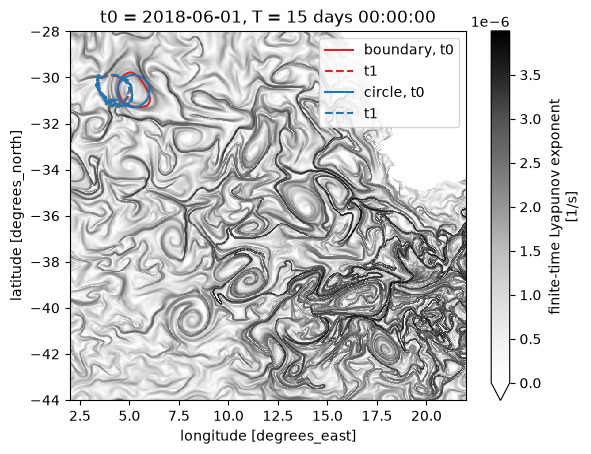

In [24]:
_, ax = plt.subplots()
ftle.plot.pcolormesh(x="lon_grid", y="lat_grid", vmin=0.0, ax=ax, cmap="Greys")
ax.plot(boundary["lon"].T, boundary["lat"].T, color="tab:red", label="boundary, t0")
ax.plot(evolved["lon"].T, evolved["lat"].T, color="tab:red", ls="--", label="t1")
ax.plot(circle["lon"].T, circle["lat"].T, color="tab:blue", label="circle, t0")
ax.plot(
    evolved_circle["lon"].T,
    evolved_circle["lat"].T,
    color="tab:blue",
    ls="--",
    label="t1",
)
ax.legend()
plt.show()

## Outcome

Of the 501 by 401 seeded particles, 19016 are lost to land or the domain edge
over the 15 days. $|\det \nabla F|$ runs from 0.255 at the 5 percent quantile
to 171 at the 95 percent, with a median of 1.28.

The search over 241 candidate centres closes 192 orbits, and
`outermost_shear_lines` keeps 12 boundaries. Six turn counter-clockwise over
the first day and six clockwise, so south of the equator six are
anticyclones and six cyclones. The largest, at $\lambda = 1.062$ with an
equivalent radius of 77.4 km and its centroid at 5.20 E 30.59 S, turns
counter-clockwise.

Carried through the flow map, that boundary's arc length grows by 1.121
against its $\lambda$ of 1.062. A circle of the same equivalent radius about
the same centroid grows by 3.371.